In [1]:
import os
#credential=os.environ['HF_TOKEN']

In [2]:
%%capture
%pip install --no-cache "data-prep-toolkit-transforms[enrichment]"
%pip install huggingface_hub
%pip install matplotlib
%pip install pandas

In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "HuggingFaceFW/fineweb"
FILENAME = "data/CC-MAIN-2013-20/000_00000.parquet"
file1 = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
input_folder= os.path.dirname(file1)

/Users/touma/data-prep-kit-pkg/examples/notebooks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
%%time
from dpk_enrichment import Enrichment

Enrichment(
    enrichment_content_column_name="text",
    enrichment_lang_column_name="language",
    enrichment_output_column_prefix="e_",
    input_folder=input_folder, 
    output_folder="tmp/enrichment" 
).transform()

11:31:04 INFO - Enrichment parameters are: {"output_column_prefix": "e_", "content_column_name": "text", "lang_column_name": "language", "newline_normalized_column_name": "", "error_column_name": "", "num_newlines_column_name": "num_newlines", "num_paragraphs_column_name": "num_paragraphs", "num_words_column_name": "num_words", "num_chars_column_name": "num_chars", "total_non_newline_chars_column_name": "total_non_newline_chars", "avg_word_length_column_name": "avg_word_length", "avg_paragraph_length_chars_column_name": "avg_paragraph_length_chars", "avg_paragraph_length_words_column_name": "avg_paragraph_length_words", "alphanumeric_char_ratio_column_name": "alphanumeric_char_ratio", "control_char_ratio_column_name": "control_char_ratio", "punctuation_char_ratio_column_name": "punctuation_char_ratio", "other_symbol_char_ratio_column_name": "other_symbol_char_ratio", "tabs_word_ratio_column_name": "tabs_word_ratio", "hashes_word_ratio_column_name": "hashes_word_ratio", "ellipsis_ratio_

CPU times: user 1h 10min 41s, sys: 43.1 s, total: 1h 11min 24s
Wall time: 1h 12min 32s


0

In [5]:
import pandas as pd
df = pd.read_parquet('tmp/enrichment/000_00000.parquet')

In [6]:
df.columns

Index(['text', 'id', 'dump', 'url', 'date', 'file_path', 'language',
       'language_score', 'token_count', 'e_num_newlines', 'e_num_paragraphs',
       'e_num_words', 'e_num_chars', 'e_total_non_newline_chars',
       'e_avg_word_length', 'e_avg_paragraph_length_chars',
       'e_avg_paragraph_length_words', 'e_alphanumeric_char_ratio',
       'e_control_char_ratio', 'e_punctuation_char_ratio',
       'e_other_symbol_char_ratio', 'e_tabs_word_ratio', 'e_hashes_word_ratio',
       'e_ellipsis_ratio', 'e_bulletpoint_ratio', 'e_dup_paragraphs_ratio',
       'e_dup_paragraphs_char_ratio', 'e_top_2_gram_char_ratio',
       'e_top_3_gram_char_ratio', 'e_top_4_gram_char_ratio',
       'e_dup_5_gram_char_ratio', 'e_dup_6_gram_char_ratio',
       'e_dup_7_gram_char_ratio', 'e_dup_8_gram_char_ratio',
       'e_dup_9_gram_char_ratio', 'e_dup_10_gram_char_ratio'],
      dtype='object')

<Axes: >

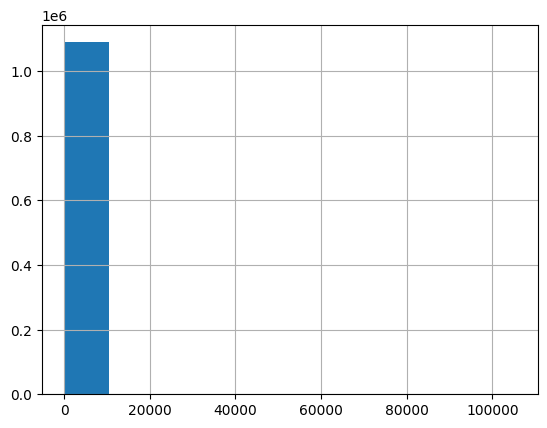

In [7]:
import matplotlib.pyplot as plt
df['e_num_words'].hist()

In [8]:
len(df[df['e_num_words'] > 2000])/len(df)

0.03750884188690448

<Axes: >

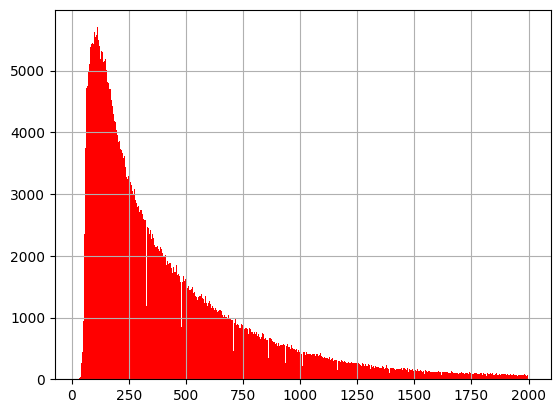

In [10]:
 df[df['e_num_words']< 2000]['e_num_words'].hist(bins=1000, color='red')